In [1]:
# Cell 2: imports & device
import os
import random
from pathlib import Path
from glob import glob
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils
import torchvision.transforms.functional as TF

# helpful utils
import numpy as np
from tqdm.notebook import tqdm

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [2]:
# Cell 3: dataset and output paths
ROOT = Path("/home/rifat-cou/Documents/Cowpox_Project")

TRAIN_A = ROOT / "trainA"   # ROI semantic maps (inputs for refiner)
TRAIN_B = ROOT / "trainB"   # real images (targets)
VAL_A   = ROOT / "valA"
VAL_B   = ROOT / "valB"

# create folders for checkpoints and outputs
OUT_DIR = ROOT / "outputs"
AE_DIR = ROOT / "ae"
DIFF_DIR = ROOT / "diffusion"
REFINER_DIR = ROOT / "refiner"
for d in [OUT_DIR, AE_DIR, DIFF_DIR, REFINER_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("TrainA count:", len(list(TRAIN_A.glob("*"))))
print("TrainB count:", len(list(TRAIN_B.glob("*"))))
print("ValA count:",   len(list(VAL_A.glob("*"))))
print("ValB count:",   len(list(VAL_B.glob("*"))))


TrainA count: 2300
TrainB count: 2300
ValA count: 576
ValB count: 576


In [3]:
from pathlib import Path

base = Path("/home/rifat-cou/Documents/Cowpox_Project")
for folder in ["trainA", "trainB", "valA", "valB"]:
    files = list((base / folder).glob("*"))
    print(f"{folder}: {len(files)} files, example: {[f.name for f in files[:5]]}")


trainA: 2300 files, example: ['Cowpox_016_02_map.png', 'Cowpox_011_03_map.png', 'Cowpox_035_19_map.png', 'Cowpox_053_18_map.png', 'Cowpox_012_13_map.png']
trainB: 2300 files, example: ['Cowpox_012_14_real.png', 'Cowpox_052_17_real.png', 'Cowpox_090_24_real.png', 'Cowpox_034_10_real.png', 'Cowpox_086_27_real.png']
valA: 576 files, example: ['Cowpox_083_01_map.png', 'Cowpox_079_02_map.png', 'Cowpox_061_21_map.png', 'Cowpox_039_12_map.png', 'Cowpox_053_03_map.png']
valB: 576 files, example: ['Cowpox_107_real.png', 'Cowpox_083_13_real.png', 'Cowpox_060_28_real.png', 'Cowpox_057_20_real.png', 'Cowpox_028_27_real.png']


In [4]:
for folder in ["trainA", "trainB", "valA", "valB"]:
    files = sorted([f.name for f in (base / folder).glob("*")])[:5]
    print(f"{folder}: {files}")


trainA: ['Cowpox_001_02_map.png', 'Cowpox_001_03_map.png', 'Cowpox_001_04_map.png', 'Cowpox_001_05_map.png', 'Cowpox_001_07_map.png']
trainB: ['Cowpox_001_02_real.png', 'Cowpox_001_03_real.png', 'Cowpox_001_04_real.png', 'Cowpox_001_05_real.png', 'Cowpox_001_07_real.png']
valA: ['Cowpox_001_01_map.png', 'Cowpox_001_06_map.png', 'Cowpox_001_11_map.png', 'Cowpox_001_14_map.png', 'Cowpox_001_17_map.png']
valB: ['Cowpox_001_01_real.png', 'Cowpox_001_06_real.png', 'Cowpox_001_11_real.png', 'Cowpox_001_14_real.png', 'Cowpox_001_17_real.png']


In [5]:
# Cell 4: sanity: ensure counts line up (for paired usage later)
ta = sorted([p.name for p in TRAIN_A.glob("*")])
tb = sorted([p.name for p in TRAIN_B.glob("*")])
print("trainA examples:", len(ta))
print("trainB examples:", len(tb))

# If filenames match pairwise, good. If not, we will assume the same sorting aligns pairs.
# Show first 5 file names (trainA/trainB)
for i in range(min(5, len(ta), len(tb))):
    print(i, ta[i], " <-> ", tb[i])


trainA examples: 2300
trainB examples: 2300
0 Cowpox_001_02_map.png  <->  Cowpox_001_02_real.png
1 Cowpox_001_03_map.png  <->  Cowpox_001_03_real.png
2 Cowpox_001_04_map.png  <->  Cowpox_001_04_real.png
3 Cowpox_001_05_map.png  <->  Cowpox_001_05_real.png
4 Cowpox_001_07_map.png  <->  Cowpox_001_07_real.png


In [6]:
# Cell 5: transforms & helper functions
IMAGE_SIZE = 256   # target crop/resize for both AE/diffusion and refiner

to_tensor = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),              # [0,1]
    transforms.Normalize([0.5]*3, [0.5]*3)  # [-1,1]
])

to_tensor_gray = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

def load_image(path, rgb=True, size=IMAGE_SIZE):
    im = Image.open(path)
    if rgb:
        im = im.convert("RGB")
        im = im.resize((size, size))
    else:
        im = im.convert("L")
        im = im.resize((size, size))
    return im

def show_images_grid(imgs, titles=None, figsize=(10,6)):
    n = len(imgs)
    cols = min(4, n)
    rows = (n + cols - 1) // cols
    plt.figure(figsize=figsize)
    for i, im in enumerate(imgs):
        plt.subplot(rows, cols, i+1)
        if isinstance(im, torch.Tensor):
            im = im.cpu().detach()
            im = im * 0.5 + 0.5
            im = TF.to_pil_image(im)
        plt.imshow(im)
        plt.axis('off')
        if titles:
            plt.title(titles[i])
    plt.show()


Images in AE dataset: 2300


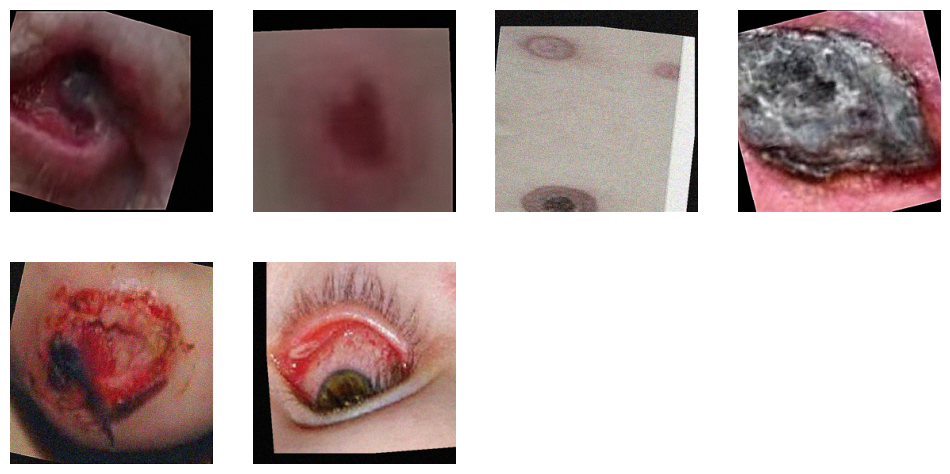

In [7]:
# Cell 6: simple dataset for training autoencoder / diffusion on raw images (trainB)
class ImageFolderDataset(Dataset):
    def __init__(self, folder, transform=to_tensor):
        self.paths = sorted([str(p) for p in Path(folder).glob("*") if p.suffix.lower() in [".jpg",".png",".jpeg"]])
        self.transform = transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        p = self.paths[idx]
        img = Image.open(p).convert("RGB")
        return self.transform(img), os.path.basename(p)

# quick loader
img_ds = ImageFolderDataset(TRAIN_B)
print("Images in AE dataset:", len(img_ds))
# preview a few
sample_imgs = [Image.open(p).convert("RGB").resize((IMAGE_SIZE,IMAGE_SIZE)) for p in list(TRAIN_B.glob("*"))[:6]]
show_images_grid(sample_imgs, figsize=(12,6))


Hybrid pairs: 2300


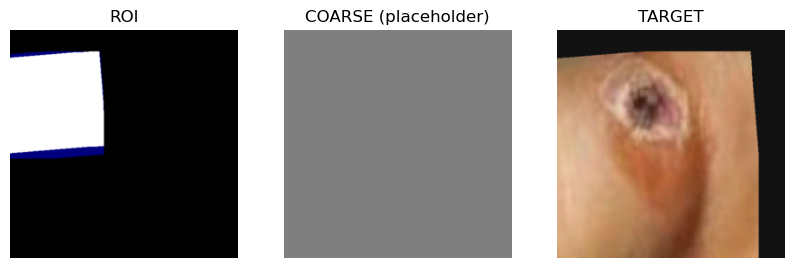

In [8]:
# Cell 7: Hybrid dataset (ROI semantic map + coarse image -> target real)
class HybridPairedDataset(Dataset):
    def __init__(self, roi_dir, coarse_dir, target_dir, image_size=IMAGE_SIZE):
        self.roi_paths = sorted([str(p) for p in Path(roi_dir).glob("*") if p.suffix.lower() in [".jpg",".png",".jpeg"]])
        self.target_paths = sorted([str(p) for p in Path(target_dir).glob("*") if p.suffix.lower() in [".jpg",".png",".jpeg"]])
        self.coarse_dir = Path(coarse_dir) if coarse_dir else None
        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3)
        ])
        assert len(self.roi_paths) == len(self.target_paths), "roi and target counts differ"
    def __len__(self):
        return len(self.roi_paths)
    def __getitem__(self, idx):
        roi_p = self.roi_paths[idx]
        tgt_p = self.target_paths[idx]
        roi_img = Image.open(roi_p).convert("RGB")   # semantic map as 3-channel RGB
        tgt_img = Image.open(tgt_p).convert("RGB")
        if self.coarse_dir:
            # assume coarse images are saved with the same basename into coarse_dir
            coarse_p = self.coarse_dir / Path(tgt_p).name
            if coarse_p.exists():
                coarse_img = Image.open(coarse_p).convert("RGB")
            else:
                # fallback: blank / noisy input
                coarse_img = Image.new("RGB", roi_img.size, (127,127,127))
        else:
            coarse_img = Image.new("RGB", roi_img.size, (127,127,127))
        # transforms
        roi_t = self.transform(roi_img)
        coarse_t = self.transform(coarse_img)
        tgt_t = self.transform(tgt_img)
        # input channels = 6 (roi + coarse)
        inp = torch.cat([roi_t, coarse_t], dim=0)
        return inp, tgt_t, os.path.basename(tgt_p)

# quick instantiation (coarse_dir currently None)
hybrid_ds = HybridPairedDataset(TRAIN_A, coarse_dir=None, target_dir=TRAIN_B)
print("Hybrid pairs:", len(hybrid_ds))
# show a sample: roi, (blank)coarse, target
inp, tgt, name = hybrid_ds[0]
# split input channels to 2 images
roi_img = inp[:3]; coarse_img = inp[3:]
show_images_grid([roi_img, coarse_img, tgt], titles=["ROI", "COARSE (placeholder)", "TARGET"])


In [9]:
# Cell 8: DataLoaders
batch_size = 4

ae_loader = DataLoader(ImageFolderDataset(TRAIN_B), batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
hybrid_loader = DataLoader(HybridPairedDataset(TRAIN_A, coarse_dir=None, target_dir=TRAIN_B), batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

# quick fetch
x_batch, names = next(iter(ae_loader))
print("AE batch shape:", x_batch.shape)   # [B, 3, H, W]

inp_batch, tgt_batch, names2 = next(iter(hybrid_loader))
print("Hybrid input shape:", inp_batch.shape, " -> target:", tgt_batch.shape)  # [B, 6, H, W] -> [B, 3, H, W]


AE batch shape: torch.Size([4, 3, 256, 256])
Hybrid input shape: torch.Size([4, 6, 256, 256])  -> target: torch.Size([4, 3, 256, 256])


In [10]:
# Cell 9: simple conv autoencoder (toy; replace with a stronger AE later)
class SimpleEncoder(nn.Module):
    def __init__(self, z_channels=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),  # 128
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1), #64
            nn.InstanceNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, 2, 1), #32
            nn.InstanceNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.Conv2d(256, z_channels, 4, 2, 1), #16
        )
    def forward(self, x):
        return self.net(x)

class SimpleDecoder(nn.Module):
    def __init__(self, z_channels=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_channels, 256, 4, 2, 1), #32
            nn.ReLU(),
            nn.ConvTranspose2d(256, 128, 4, 2, 1), #64
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), #128
            nn.ReLU(),
            nn.ConvTranspose2d(64, 3, 4, 2, 1), #256
            nn.Tanh()
        )
    def forward(self, z):
        return self.net(z)

# instantiate
z_ch = 64
encoder = SimpleEncoder(z_channels=z_ch).to(device)
decoder = SimpleDecoder(z_channels=z_ch).to(device)

# quick single-epoch train (sanity run)
opt = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=2e-4)
l1 = nn.L1Loss()

# one quick epoch over small subset to ensure no runtime errors
print("Starting quick AE sanity run (1 epoch over a few batches)...")
encoder.train(); decoder.train()
for i, (x,_) in enumerate(ae_loader):
    if i>10: break
    x = x.to(device)
    z = encoder(x)
    recon = decoder(z)
    loss = l1(recon, x)
    opt.zero_grad(); loss.backward(); opt.step()
    if i % 5 == 0:
        print(f"iter {i} loss {loss.item():.4f}")
print("Sanity run completed.")


Starting quick AE sanity run (1 epoch over a few batches)...
iter 0 loss 0.4604
iter 5 loss 0.3661
iter 10 loss 0.3655
Sanity run completed.


In [11]:
# Cell 10: stronger Autoencoder with perceptual loss
import torchvision.models as models

class Encoder(nn.Module):
    def __init__(self, z_channels=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),  # ->128
            nn.BatchNorm2d(64), nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1),  # ->64
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, 2, 1),  # ->32
            nn.BatchNorm2d(256), nn.LeakyReLU(0.2),
            nn.Conv2d(256, 512, 4, 2, 1),  # ->16
            nn.BatchNorm2d(512), nn.LeakyReLU(0.2),
            nn.Conv2d(512, z_channels, 4, 2, 1)  # ->8
        )
    def forward(self, x):
        return self.net(x)

class Decoder(nn.Module):
    def __init__(self, z_channels=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_channels, 512, 4, 2, 1), #16
            nn.BatchNorm2d(512), nn.ReLU(True),
            nn.ConvTranspose2d(512, 256, 4, 2, 1), #32
            nn.BatchNorm2d(256), nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1), #64
            nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),  #128
            nn.BatchNorm2d(64), nn.ReLU(True),
            nn.ConvTranspose2d(64, 3, 4, 2, 1),    #256
            nn.Tanh()
        )
    def forward(self, z):
        return self.net(z)

# ---- fixed VGG Feature Extractor ----
from torchvision.models import vgg19, VGG19_Weights

class VGGFeatureExtractor(nn.Module):
    def __init__(self, layers=[3, 8, 15, 22]):
        super().__init__()
        vgg = vgg19(weights=VGG19_Weights.IMAGENET1K_V1).features.eval()
        self.selected_layers = layers
        self.vgg_layers = vgg[:max(layers)+1]
        for p in self.vgg_layers.parameters():
            p.requires_grad = False
    def forward(self, x):
        feats = []
        for i, layer in enumerate(self.vgg_layers):
            x = layer(x)
            if i in self.selected_layers:
                feats.append(x)
        return feats


In [12]:
# Cell 11: training setup
encoder = Encoder(z_channels=64).to(device)
decoder = Decoder(z_channels=64).to(device)
vgg_feat = VGGFeatureExtractor().to(device)

criterion_L1 = nn.L1Loss()
optimizer = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=2e-4, betas=(0.5, 0.999))

start_epochs = 600
num_epochs = 700   # start with 50, can go up to 200 if dataset small
λ_perc = 1.0      # perceptual loss weight

print("Training AE with perceptual loss...")


Training AE with perceptual loss...


In [13]:
AE_DIR.mkdir(parents=True, exist_ok=True)
DIFF_DIR.mkdir(parents=True, exist_ok=True)
REFINER_DIR.mkdir(parents=True, exist_ok=True)

# === 1. Autoencoder ===
encoder_path = AE_DIR / "encoder.pt"
decoder_path = AE_DIR / "decoder.pt"

if encoder_path.exists() and decoder_path.exists():
    encoder.load_state_dict(torch.load(encoder_path, map_location=device))
    decoder.load_state_dict(torch.load(decoder_path, map_location=device))
    print("✅ Loaded encoder/decoder checkpoints")
else:
    print("⚠️ No AE checkpoints found — you’ll need to retrain the autoencoder first.")


✅ Loaded encoder/decoder checkpoints


In [14]:
# Cell 12: training loop
encoder.train(); decoder.train()

save_path_enc = str(AE_DIR / "encoder.pt")
save_path_dec = str(AE_DIR / "decoder.pt")

for epoch in range(start_epochs, num_epochs):
    epoch_loss = 0
    for imgs, _ in tqdm(ae_loader, total=len(ae_loader), desc=f"Epoch {epoch+1}/{num_epochs}"):
        imgs = imgs.to(device)
        z = encoder(imgs)
        recon = decoder(z)
        # perceptual loss
        f_real = vgg_feat((imgs+1)/2)  # rescale to [0,1] for VGG
        f_fake = vgg_feat((recon+1)/2)
        perc_loss = sum([criterion_L1(a, b) for a, b in zip(f_real, f_fake)]) / len(f_real)
        l1_loss = criterion_L1(recon, imgs)
        loss = l1_loss + λ_perc * perc_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}: loss={epoch_loss/len(ae_loader):.4f}")

    # save checkpoints every 50 epochs
    if (epoch+1) % 50 == 0:
        torch.save(encoder.state_dict(), save_path_enc)
        torch.save(decoder.state_dict(), save_path_dec)
        print(f"Checkpoint saved at epoch {epoch+1}")


Epoch 601/700:   0%|          | 0/575 [00:00<?, ?it/s]

Epoch 601: loss=0.1785


Epoch 602/700:   0%|          | 0/575 [00:00<?, ?it/s]

Epoch 602: loss=0.1783


Epoch 603/700:   0%|          | 0/575 [00:00<?, ?it/s]

...

Epoch 698: loss=0.1769


Epoch 699/700:   0%|          | 0/575 [00:00<?, ?it/s]

Epoch 699: loss=0.1768


Epoch 700/700:   0%|          | 0/575 [00:00<?, ?it/s]

Epoch 700: loss=0.1764
Checkpoint saved at epoch 700


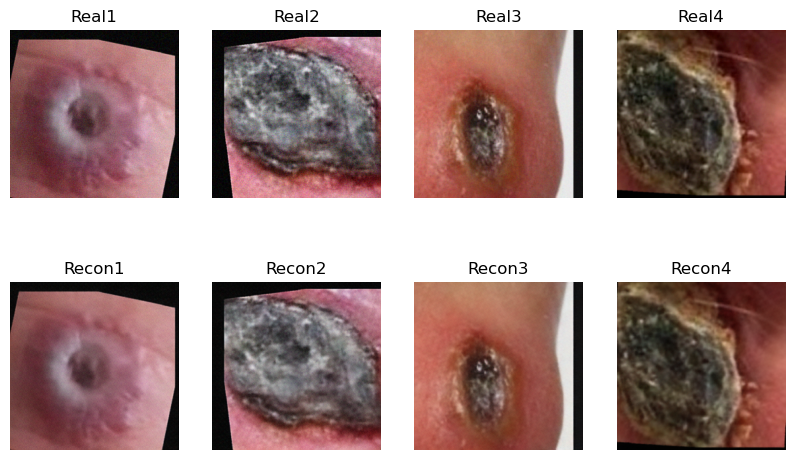

In [15]:
# Cell 13: visualize reconstructions
encoder.eval(); decoder.eval()

imgs, _ = next(iter(ae_loader))
imgs = imgs.to(device)
with torch.no_grad():
    z = encoder(imgs)
    recon = decoder(z)

# show first 4 images
real_imgs = imgs[:4]
recon_imgs = recon[:4]
show_images_grid([real_imgs[i] for i in range(4)] + [recon_imgs[i] for i in range(4)],
                 titles=["Real1","Real2","Real3","Real4","Recon1","Recon2","Recon3","Recon4"],
                 figsize=(10,6))


In [16]:
# Cell A
import math
import numpy as np
import torch.nn.functional as F

def linear_beta_schedule(timesteps, beta_start=1e-4, beta_end=2e-2):
    return torch.linspace(beta_start, beta_end, timesteps)

def get_alphas(betas):
    alphas = 1.0 - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)
    return alphas, alphas_cumprod

def q_sample(x0, t, noise, sqrt_alphas_cumprod, sqrt_one_minus_alphas_cumprod):
    # x0: [B, C, H, W]
    # t: [B] int timesteps
    # noise: same shape as x0
    # Use broadcasting
    return (sqrt_alphas_cumprod[t].view(-1,1,1,1) * x0 +
            sqrt_one_minus_alphas_cumprod[t].view(-1,1,1,1) * noise)

class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        device = t.device
        half = self.dim // 2
        emb = math.log(10000) / (half - 1)
        emb = torch.exp(torch.arange(half, device=device) * -emb)
        emb = t[:, None].float() * emb[None, :]
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)
        return emb


In [17]:
# Cell B
# ✅ FIXED LatentUNet that auto-aligns tensor sizes before concatenation
class Block(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, 1, 1),
            nn.GroupNorm(8, out_ch),
            nn.SiLU(),
            nn.Conv2d(out_ch, out_ch, 3, 1, 1),
            nn.GroupNorm(8, out_ch),
            nn.SiLU(),
        )
    def forward(self, x): 
        return self.block(x)

def center_crop_or_pad(a, b):
    """Resize tensor a spatially to match tensor b (via center crop or pad)."""
    _, _, ha, wa = a.shape
    _, _, hb, wb = b.shape
    diff_h = hb - ha
    diff_w = wb - wa
    if diff_h > 0 or diff_w > 0:
        a = F.pad(a, [diff_w // 2, diff_w - diff_w // 2,
                      diff_h // 2, diff_h - diff_h // 2])
    elif diff_h < 0 or diff_w < 0:
        a = a[:, :, (-diff_h)//2:ha + diff_h//2, (-diff_w)//2:wa + diff_w//2]
    return a

class LatentUNet(nn.Module):
    def __init__(self, z_channels=64, base=128, time_emb_dim=256):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, base)
        )
        # down
        self.conv_in = nn.Conv2d(z_channels, base, 3, 1, 1)
        self.down1 = Block(base, base)
        self.down2 = Block(base, base*2)
        self.down3 = Block(base*2, base*2)
        # up
        self.up3 = Block(base*2 + base*2, base*2)
        self.up2 = Block(base*2 + base, base)
        self.up1 = Block(base + base, base)
        self.conv_out = nn.Conv2d(base, z_channels, 3, 1, 1)

        self.pool = nn.AvgPool2d(2)
        self.up = nn.Upsample(scale_factor=2, mode='nearest')

    def forward(self, x, t):
        t_emb = self.time_mlp(t)[:, :, None, None]
        h = self.conv_in(x) + t_emb
        h1 = self.down1(h)
        h2 = self.down2(self.pool(h1))
        h3 = self.down3(self.pool(h2))

        u3 = self.up(h3)
        u3 = center_crop_or_pad(u3, h2)
        u3 = torch.cat([u3, h2], dim=1)
        u3 = self.up3(u3)

        u2 = self.up(u3)
        u2 = center_crop_or_pad(u2, h1)
        u2 = torch.cat([u2, h1], dim=1)
        u2 = self.up2(u2)

        u1 = self.up(u2)
        u1 = center_crop_or_pad(u1, h)
        u1 = torch.cat([u1, h], dim=1)
        u1 = self.up1(u1)

        out = self.conv_out(u1)
        return out


In [18]:
# ✅ FIXED Cell C
encoder.eval()
for p in encoder.parameters():
    p.requires_grad = False

class LatentDataset(Dataset):
    def __init__(self, image_folder, encoder, transform=None):
        self.paths = sorted([str(p) for p in Path(image_folder).glob("*") if p.suffix.lower() in [".jpg",".png",".jpeg"]])
        self.encoder = encoder.to(device)  # move encoder to GPU once
        self.transform = transform if transform is not None else to_tensor
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        p = self.paths[idx]
        img = Image.open(p).convert('RGB')
        x = self.transform(img).unsqueeze(0).to(device)
        with torch.no_grad():
            z = self.encoder(x)
        z = z.squeeze(0).cpu()  # move latent to CPU for DataLoader
        return z, os.path.basename(p)

# ✅ Set num_workers=0 to avoid CUDA fork issue
train_latent_ds = LatentDataset(str(TRAIN_B), encoder)
val_latent_ds = LatentDataset(str(VAL_B), encoder)
train_latent_dl = DataLoader(train_latent_ds, batch_size=4, shuffle=True, num_workers=0)
val_latent_dl = DataLoader(val_latent_ds, batch_size=4, shuffle=False, num_workers=0)

z_sample, name = train_latent_ds[0]
print("Sample latent shape:", z_sample.shape)


Sample latent shape: torch.Size([64, 8, 8])


In [19]:
# Cell D
# Hyperparams
timesteps = 1000
betas = linear_beta_schedule(timesteps).to(device)
alphas, alphas_cumprod = get_alphas(betas)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod).to(device)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1 - alphas_cumprod).to(device)

z_ch, hz, wz = z_sample.shape
model = LatentUNet(z_channels=z_ch, base=128, time_emb_dim=256).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=1e-4)
mse = nn.MSELoss()

start_epochs = 500
num_epochs = 700  # adjust for your time budget
save_every = 50

# === 2. DDPM ===
latest_ddpm_ckpt = max(DIFF_DIR.glob("*.pt"), key=lambda f: f.stat().st_mtime, default=None)
if latest_ddpm_ckpt:
    ckpt = torch.load(latest_ddpm_ckpt, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    opt.load_state_dict(ckpt["opt_state"]) if "opt_state" in ckpt else None
    start_epoch = ckpt.get("epoch", 0)
    print(f"✅ Resumed DDPM from {latest_ddpm_ckpt.name} at epoch {start_epoch}")
else:
    print("⚠️ No DDPM checkpoint found — you’ll need to retrain DDPM model.")


✅ Resumed DDPM from ddpm_epoch500.pt at epoch 500


In [21]:
print("Starting latent DDPM training...")
for epoch in range(start_epochs, num_epochs):
    model.train()
    running = 0.0
    for batch in tqdm(train_latent_dl, desc=f"Epoch {epoch+1}/{num_epochs}"):
        zs, _ = batch
        zs = zs.to(device)  # [B, z_ch, hz, wz]
        B = zs.shape[0]
        t = torch.randint(0, timesteps, (B,), device=device).long()
        noise = torch.randn_like(zs)
        zt = q_sample(zs, t, noise, sqrt_alphas_cumprod, sqrt_one_minus_alphas_cumprod)
        pred_noise = model(zt, t)
        loss = mse(pred_noise, noise)
        opt.zero_grad(); loss.backward(); opt.step()
        running += loss.item()
    avg = running / len(train_latent_dl)
    print(f"Epoch {epoch+1} avg loss: {avg:.6f}")

    # save checkpoint
    if (epoch+1) % save_every == 0 or epoch == num_epochs-1:
        ckpt = {
            "model_state": model.state_dict(),
            "opt_state": opt.state_dict(),
            "epoch": epoch+1
        }
        torch.save(ckpt, str(DIFF_DIR / f"ddpm_epoch{epoch+1}.pt"))
        print("Saved checkpoint:", DIFF_DIR / f"ddpm_epoch{epoch+1}.pt")


Starting latent DDPM training...


Epoch 501/700:   0%|          | 0/575 [00:00<?, ?it/s]

Epoch 501 avg loss: 0.673886


Epoch 502/700:   0%|          | 0/575 [00:00<?, ?it/s]

Epoch 502 avg loss: 0.663306


...

Epoch 698 avg loss: 0.660507


Epoch 699/700:   0%|          | 0/575 [00:00<?, ?it/s]

Epoch 699 avg loss: 0.652354


Epoch 700/700:   0%|          | 0/575 [00:00<?, ?it/s]

Epoch 700 avg loss: 0.657657
Saved checkpoint: /home/rifat-cou/Documents/Cowpox_Project/diffusion/ddpm_epoch700.pt


In [22]:
# Cell E
# Helper: posterior mean/std compute (standard DDPM formulas)
betas_cpu = linear_beta_schedule(timesteps)  # cpu tensor for indexing
alphas_cpu = 1.0 - betas_cpu
alphas_cumprod_cpu = torch.cumprod(alphas_cpu, dim=0)
sqrt_recip_alphas = torch.sqrt(1.0 / alphas_cpu)
posterior_variance = torch.cat([
    torch.zeros(1),
    betas_cpu[1:] * (1.0 - alphas_cumprod_cpu[:-1]) / (1.0 - alphas_cumprod_cpu[1:])
])

@torch.no_grad()
def sample_ddpm(model, n_samples, device, timesteps=1000):
    model.eval()
    # shape from encoder: use z_sample to get z_ch, hz, wz
    z_shape = (n_samples, z_ch, hz, wz)
    z_t = torch.randn(z_shape, device=device)
    for t in tqdm(reversed(range(timesteps)), desc="Sampling timesteps"):
        t_batch = torch.full((n_samples,), t, device=device, dtype=torch.long)
        pred_noise = model(z_t, t_batch)
        # compute the predicted x0
        alpha_cum = alphas_cumprod[t].to(device)
        sqrt_recip_alpha = 1.0 / torch.sqrt(alphas[t]).to(device)
        # simple DDPM posterior step (follow DDPM sampling formula)
        z0_pred = (z_t - sqrt_one_minus_alphas_cumprod[t].to(device) * pred_noise) / sqrt_alphas_cumprod[t].to(device)
        if t > 0:
            beta_t = betas[t].to(device)
            alpha_t = alphas[t].to(device)
            alpha_cum_prev = alphas_cumprod[t-1].to(device)
            # compute posterior mean
            coef1 = beta_t * torch.sqrt(alpha_cum_prev) / (1.0 - alphas_cumprod[t])
            coef2 = (1.0 - alpha_cum_prev) * torch.sqrt(alpha_t) / (1.0 - alphas_cumprod[t])
            mean = coef1 * z0_pred + coef2 * z_t
            noise = torch.randn_like(z_t)
            var = beta_t * (1.0 - alpha_cum_prev) / (1.0 - alphas_cumprod[t])
            z_t = mean + torch.sqrt(var) * noise
        else:
            # t==0 -> z0 predicted
            z_t = z0_pred
    return z_t  # shape [n, z_ch, hz, wz]

# Save directory
COARSE_TRAIN_DIR = OUT_DIR / "coarse" / "train"
COARSE_VAL_DIR = OUT_DIR / "coarse" / "val"
COARSE_TRAIN_DIR.mkdir(parents=True, exist_ok=True)
COARSE_VAL_DIR.mkdir(parents=True, exist_ok=True)

# Load last checkpoint if needed
# ckpt = torch.load(str(DIFF_DIR / "ddpm_epoch120.pt"), map_location=device)
# model.load_state_dict(ckpt["model_state"])

# Sample & decode for train set (one sample per training image)
model.eval()
n_to_sample = len(train_latent_ds)
batch_sz = 4
i = 0
for start in range(0, n_to_sample, batch_sz):
    n = min(batch_sz, n_to_sample - start)
    z_gen = sample_ddpm(model, n, device, timesteps=timesteps)  # [n, z_ch, hz, wz]
    # decode and save
    with torch.no_grad():
        decoded = []
        for k in range(n):
            z_k = z_gen[k:k+1].to(device)
            img = decoder(z_k)   # decode -> [-1,1]
            img = (img.squeeze(0).cpu() * 0.5 + 0.5).clamp(0,1)  # to [0,1]
            pil = TF.to_pil_image(img)
            # save using corresponding filename from train_latent_ds
            _, fname = train_latent_ds[start + k]
            pil.save(str(COARSE_TRAIN_DIR / fname))
    i += n
print("Saved coarse train samples to", COARSE_TRAIN_DIR)

# Sample a small set for validation (or full val set similarly)
n_val = len(val_latent_ds)
for start in range(0, n_val, batch_sz):
    n = min(batch_sz, n_val - start)
    z_gen = sample_ddpm(model, n, device, timesteps=timesteps)
    with torch.no_grad():
        for k in range(n):
            z_k = z_gen[k:k+1].to(device)
            img = decoder(z_k)
            img = (img.squeeze(0).cpu() * 0.5 + 0.5).clamp(0,1)
            pil = TF.to_pil_image(img)
            _, fname = val_latent_ds[start + k]
            pil.save(str(COARSE_VAL_DIR / fname))
print("Saved coarse val samples to", COARSE_VAL_DIR)


Sampling timesteps: 0it [00:00, ?it/s]

Sampling timesteps: 0it [00:00, ?it/s]

Sampling timesteps: 0it [00:00, ?it/s]

Sampling timesteps: 0it [00:00, ?it/s]

Sampling timesteps: 0it [00:00, ?it/s]

...

Sampling timesteps: 0it [00:00, ?it/s]

Sampling timesteps: 0it [00:00, ?it/s]

Sampling timesteps: 0it [00:00, ?it/s]

Sampling timesteps: 0it [00:00, ?it/s]

Saved coarse val samples to /home/rifat-cou/Documents/Cowpox_Project/outputs/coarse/val


In [23]:
from pathlib import Path

base = Path("/home/rifat-cou/Documents/Cowpox_Project/outputs/coarse")
all_pngs = list(base.rglob("*.png"))
print(f"🔍 Found {len(all_pngs)} PNGs under {base}")

# Show 10 random examples
for p in all_pngs[:10]:
    print(p)


🔍 Found 2876 PNGs under /home/rifat-cou/Documents/Cowpox_Project/outputs/coarse
/home/rifat-cou/Documents/Cowpox_Project/outputs/coarse/val/Cowpox_107_real.png
/home/rifat-cou/Documents/Cowpox_Project/outputs/coarse/val/Cowpox_083_13_real.png
/home/rifat-cou/Documents/Cowpox_Project/outputs/coarse/val/Cowpox_060_28_real.png
/home/rifat-cou/Documents/Cowpox_Project/outputs/coarse/val/Cowpox_057_20_real.png
/home/rifat-cou/Documents/Cowpox_Project/outputs/coarse/val/Cowpox_028_27_real.png
/home/rifat-cou/Documents/Cowpox_Project/outputs/coarse/val/Cowpox_049_02_real.png
/home/rifat-cou/Documents/Cowpox_Project/outputs/coarse/val/Cowpox_007_06_real.png
/home/rifat-cou/Documents/Cowpox_Project/outputs/coarse/val/Cowpox_027_19_real.png
/home/rifat-cou/Documents/Cowpox_Project/outputs/coarse/val/Cowpox_068_25_real.png
/home/rifat-cou/Documents/Cowpox_Project/outputs/coarse/val/Cowpox_097_real.png


In [24]:
# ✅ Cell F — Smart Refiner Dataset to handle _map/_real filename differences
from torchvision import transforms
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import re

def normalize_name(name):
    """Normalize filename to base ID (remove '_map', '_real', '_coarse', etc.)"""
    return re.sub(r'_(map|mask|roi|real|coarse)$', '', Path(name).stem)

class RefinerDataset(Dataset):
    def __init__(self, roi_dir, coarse_dir, real_dir, transform=None):
        self.roi_dir = Path(roi_dir)
        self.coarse_dir = Path(coarse_dir)
        self.real_dir = Path(real_dir)
        self.roi_paths = sorted([p for p in self.roi_dir.glob('*') if p.suffix.lower() in ['.jpg','.png','.jpeg']])
        self.transform = transform if transform else transforms.Compose([
            transforms.Resize((256,256)),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3)
        ])

        # Build lookup tables for coarse & real by base name
        self.coarse_map = {normalize_name(p.name): p for p in self.coarse_dir.glob('*')}
        self.real_map = {normalize_name(p.name): p for p in self.real_dir.glob('*')}

    def __len__(self):
        return len(self.roi_paths)

    def __getitem__(self, idx):
        roi_path = self.roi_paths[idx]
        base = normalize_name(roi_path.name)

        coarse_path = self.coarse_map.get(base)
        real_path = self.real_map.get(base)

        if coarse_path is None:
            raise FileNotFoundError(f"No coarse image for {roi_path.name}")
        if real_path is None:
            raise FileNotFoundError(f"No real image for {roi_path.name}")

        roi = Image.open(roi_path).convert('RGB')
        coarse = Image.open(coarse_path).convert('RGB')
        real = Image.open(real_path).convert('RGB')

        roi_t = self.transform(roi)
        coarse_t = self.transform(coarse)
        real_t = self.transform(real)

        input_t = torch.cat([roi_t, coarse_t], dim=0)  # [6, 256, 256]
        return input_t, real_t, roi_path.name

# ✅ Now define DataLoaders again
train_ref_ds = RefinerDataset(TRAIN_A, COARSE_TRAIN_DIR, TRAIN_B)
val_ref_ds = RefinerDataset(VAL_A, COARSE_VAL_DIR, VAL_B)

train_ref_dl = DataLoader(train_ref_ds, batch_size=2, shuffle=True, num_workers=2)
val_ref_dl = DataLoader(val_ref_ds, batch_size=2, shuffle=False, num_workers=2)

inp, tgt, nm = train_ref_ds[0]
print(f"✅ Input shape: {inp.shape}, Target shape: {tgt.shape}, File: {nm}")


✅ Input shape: torch.Size([6, 256, 256]), Target shape: torch.Size([3, 256, 256]), File: Cowpox_001_02_map.png


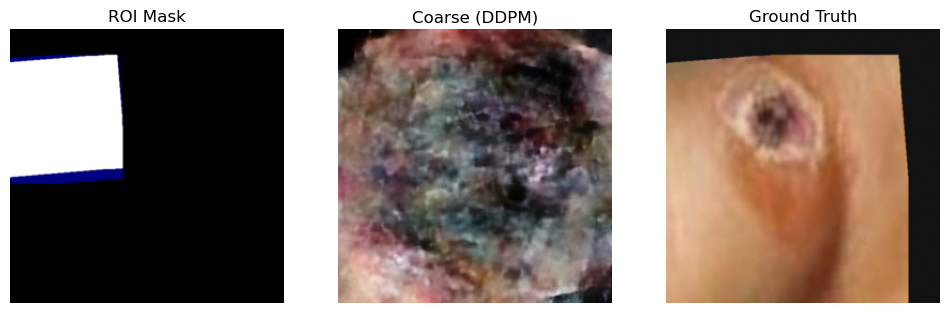

In [25]:
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF

roi = TF.to_pil_image((inp[:3]*0.5+0.5).clamp(0,1))
coarse = TF.to_pil_image((inp[3:]*0.5+0.5).clamp(0,1))
real = TF.to_pil_image((tgt*0.5+0.5).clamp(0,1))

fig, axs = plt.subplots(1,3,figsize=(12,4))
axs[0].imshow(roi); axs[0].set_title("ROI Mask")
axs[1].imshow(coarse); axs[1].set_title("Coarse (DDPM)")
axs[2].imshow(real); axs[2].set_title("Ground Truth")
for a in axs: a.axis('off')
plt.show()


In [26]:
# Cell G — Pix2Pix generator & discriminator
import torch.nn as nn

class UNetBlock(nn.Module):
    def __init__(self, in_ch, out_ch, down=True, act='relu', use_bn=True):
        super().__init__()
        if down:
            layers = [nn.Conv2d(in_ch, out_ch, 4, 2, 1, bias=False)]
        else:
            layers = [nn.ConvTranspose2d(in_ch, out_ch, 4, 2, 1, bias=False)]
        if use_bn:
            layers.append(nn.BatchNorm2d(out_ch))
        if act == 'relu':
            layers.append(nn.ReLU(inplace=True))
        else:
            layers.append(nn.LeakyReLU(0.2, inplace=True))
        self.block = nn.Sequential(*layers)
    def forward(self, x):
        return self.block(x)

class UNetGenerator(nn.Module):
    def __init__(self, in_ch=6, out_ch=3):
        super().__init__()
        self.down1 = UNetBlock(in_ch, 64, down=True, act='lrelu', use_bn=False)
        self.down2 = UNetBlock(64, 128, down=True, act='lrelu')
        self.down3 = UNetBlock(128, 256, down=True, act='lrelu')
        self.down4 = UNetBlock(256, 512, down=True, act='lrelu')
        self.down5 = UNetBlock(512, 512, down=True, act='lrelu')
        self.down6 = UNetBlock(512, 512, down=True, act='lrelu')
        self.up1 = UNetBlock(512, 512, down=False)
        self.up2 = UNetBlock(1024, 512, down=False)
        self.up3 = UNetBlock(1024, 256, down=False)
        self.up4 = UNetBlock(512, 128, down=False)
        self.up5 = UNetBlock(256, 64, down=False)
        self.final = nn.Sequential(
            nn.ConvTranspose2d(128, out_ch, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        d5 = self.down5(d4)
        d6 = self.down6(d5)
        u1 = self.up1(d6)
        u2 = self.up2(torch.cat([u1, d5], 1))
        u3 = self.up3(torch.cat([u2, d4], 1))
        u4 = self.up4(torch.cat([u3, d3], 1))
        u5 = self.up5(torch.cat([u4, d2], 1))
        out = self.final(torch.cat([u5, d1], 1))
        return out

class PatchDiscriminator(nn.Module):
    def __init__(self, in_ch=9):
        super().__init__()
        def block(in_f, out_f, norm=True):
            layers = [nn.Conv2d(in_f, out_f, 4, 2, 1)]
            if norm: layers.append(nn.BatchNorm2d(out_f))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.model = nn.Sequential(
            *block(in_ch, 64, norm=False),
            *block(64, 128),
            *block(128, 256),
            nn.Conv2d(256, 1, 4, 1, 1)
        )

    def forward(self, x, y):
        # concat input and target images
        inp = torch.cat([x, y], dim=1)
        return self.model(inp)


In [27]:
# Cell H — Loss functions, optimizers, and training loop
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

netG = UNetGenerator().to(device)
netD = PatchDiscriminator().to(device)

bce = nn.BCEWithLogitsLoss()
l1 = nn.L1Loss()

optG = torch.optim.Adam(netG.parameters(), lr=2e-4, betas=(0.5, 0.999))
optD = torch.optim.Adam(netD.parameters(), lr=2e-4, betas=(0.5, 0.999))

num_epochs = 700
lambda_L1 = 100.0

latest_gen_ckpt = max(REFINER_DIR.glob("refinerG_epoch*.pt"), key=lambda f: f.stat().st_mtime, default=None)
latest_disc_ckpt = max(REFINER_DIR.glob("refinerD_epoch*.pt"), key=lambda f: f.stat().st_mtime, default=None)

if latest_gen_ckpt:
    netG.load_state_dict(torch.load(latest_gen_ckpt, map_location=device))
    print(f"✅ Loaded Generator from {latest_gen_ckpt.name}")
else:
    print("⚠️ No Generator checkpoint found — training will start fresh.")

if latest_disc_ckpt:
    netD.load_state_dict(torch.load(latest_disc_ckpt, map_location=device))
    print(f"✅ Loaded Discriminator from {latest_disc_ckpt.name}")
else:
    print("⚠️ No Discriminator checkpoint found — training will start fresh.")




✅ Loaded Generator from refinerG_epoch500.pt
⚠️ No Discriminator checkpoint found — training will start fresh.


In [28]:
start_epochs = 500
for epoch in range(start_epochs, num_epochs):
    netG.train()
    for x, y, _ in tqdm(train_ref_dl, desc=f"Epoch {epoch+1}/{num_epochs}"):
        x, y = x.to(device), y.to(device)
        # --- Train Discriminator ---
        fake_y = netG(x).detach()
        real_pred = netD(x, y)
        fake_pred = netD(x, fake_y)
        lossD_real = bce(real_pred, torch.ones_like(real_pred))
        lossD_fake = bce(fake_pred, torch.zeros_like(fake_pred))
        lossD = (lossD_real + lossD_fake) * 0.5
        optD.zero_grad()
        lossD.backward()
        optD.step()

        # --- Train Generator ---
        fake_y = netG(x)
        fake_pred = netD(x, fake_y)
        lossG_adv = bce(fake_pred, torch.ones_like(fake_pred))
        lossG_l1 = l1(fake_y, y) * lambda_L1
        lossG = lossG_adv + lossG_l1
        optG.zero_grad()
        lossG.backward()
        optG.step()

    print(f"Epoch {epoch+1} | Loss_D: {lossD.item():.4f} | Loss_G: {lossG.item():.4f}")
    if (epoch+1) % 50 == 0:
        torch.save(netG.state_dict(), str(REFINER_DIR /f"refinerG_epoch{epoch+1}.pt"))

Epoch 501/700: 100%|████████████████████████| 1150/1150 [01:17<00:00, 14.78it/s]


Epoch 501 | Loss_D: 0.4884 | Loss_G: 15.2154


Epoch 502/700: 100%|████████████████████████| 1150/1150 [01:17<00:00, 14.77it/s]


Epoch 502 | Loss_D: 0.5893 | Loss_G: 7.8526


Epoch 503/700: 100%|████████████████████████| 1150/1150 [01:17<00:00, 14.78it/s]


...

Epoch 698 | Loss_D: 0.4140 | Loss_G: 8.0652


Epoch 699/700: 100%|████████████████████████| 1150/1150 [01:17<00:00, 14.82it/s]


Epoch 699 | Loss_D: 0.5859 | Loss_G: 5.8941


Epoch 700/700: 100%|████████████████████████| 1150/1150 [01:17<00:00, 14.82it/s]


Epoch 700 | Loss_D: 0.4535 | Loss_G: 8.8248


In [33]:
# Cell I — Generate refined images
from torchvision.utils import save_image

OUT_REF_DIR = OUT_DIR / "Generated"
OUT_REF_DIR.mkdir(parents=True, exist_ok=True)

netG.eval()
with torch.no_grad():
    for x, y, name in tqdm(val_ref_dl, desc="Generating refined samples"):
        x = x.to(device)
        fake_y = netG(x)
        for i in range(fake_y.size(0)):
            out = (fake_y[i] * 0.5 + 0.5).clamp(0,1)
            save_image(out, OUT_REF_DIR / name[i])

print(f"Saved refined images to: {OUT_REF_DIR}")


Generating refined samples: 100%|█████████████| 288/288 [00:13<00:00, 22.12it/s]

Saved refined images to: /home/rifat-cou/Documents/Cowpox_Project/outputs/Generated


In [35]:
#Filter Generated images
import cv2
import os
import numpy as np
from tqdm import tqdm
from pathlib import Path
from matplotlib import pyplot as plt
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [36]:
generated_img = "/home/rifat-cou/Documents/Cowpox_Project/outputs/Generated"
filter_dir = Path("/home/rifat-cou/Documents/Cowpox_Project/outputs/filter_output1")
filter_dir.mkdir(parents=True, exist_ok=True)

# Create subfolders for each filter
filter_names = ["mean", "gaussian", "median", "bilateral", "nlm", "laplacian", "sobel", "highpass", "unsharp", "box", "gaussian", "median", "bilateral", "motion", "lowpass", "highpass", "bandpass", "bandstop", "ideal", "butterworth"]
for name in filter_names:
    os.makedirs(os.path.join(filter_dir, name), exist_ok=True)

# Get all image paths
image_paths = [os.path.join(generated_img, f) for f in os.listdir(generated_img)
               if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

print(f"Total images found: {len(image_paths)}")

Total images found: 576


In [38]:
#Noise Removal Filters(Smoothing Filters)
def apply_mean_filter(img):
        return cv2.blur(img, (5, 5))  # 5x5 kernel average blur

def apply_gaussian_filter(img):
    return cv2.GaussianBlur(img, (5, 5), 0)  # Gaussian smoothing

def apply_median_filter(img):
    return cv2.medianBlur(img, 5)  # Median filtering (kernel 5)

def apply_bilateral_filter(img):
    return cv2.bilateralFilter(img, 9, 75, 75)  # Edge-preserving denoise

def apply_nlm_filter(img):
    # Non-local means denoising (advanced smoothing)
    return cv2.fastNlMeansDenoisingColored(img, None, 10, 10, 7, 21)

In [39]:
#Sharpening Filters
def apply_laplacian_filter(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    lap = cv2.Laplacian(gray, cv2.CV_64F)
    lap = cv2.convertScaleAbs(lap)
    sharp = cv2.addWeighted(img, 1.0, cv2.cvtColor(lap, cv2.COLOR_GRAY2RGB), 0.5, 0)
    return sharp

def apply_sobel_filter(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    sobel = cv2.magnitude(sobelx, sobely)
    sobel = cv2.convertScaleAbs(sobel)
    sharp = cv2.addWeighted(img, 1.0, cv2.cvtColor(sobel, cv2.COLOR_GRAY2RGB), 0.5, 0)
    return sharp

def apply_highpass_filter(img):
    # Convert to grayscale and apply Gaussian blur
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    low_pass = cv2.GaussianBlur(gray, (9,9), 10)
    high_pass = cv2.subtract(gray, low_pass)
    high_pass = cv2.convertScaleAbs(high_pass)
    sharp = cv2.addWeighted(img, 1.0, cv2.cvtColor(high_pass, cv2.COLOR_GRAY2RGB), 0.7, 0)
    return sharp

def apply_unsharp_mask(img):
    # Create blurred image and subtract it from original
    blur = cv2.GaussianBlur(img, (0,0), 3)
    sharp = cv2.addWeighted(img, 1.5, blur, -0.5, 0)
    return sharp


In [40]:
#Blurring/Smoothing Filters
def apply_box_blur(img):
    # Simple average blur
    return cv2.blur(img, (5,5))

def apply_gaussian_blur(img):
    # Gaussian blur with sigma = 0
    return cv2.GaussianBlur(img, (5,5), 0)

def apply_median_blur(img):
    # Median blur removes salt-and-pepper noise
    return cv2.medianBlur(img, 5)

def apply_bilateral_blur(img):
    # Edge-preserving smoothing filter
    return cv2.bilateralFilter(img, 9, 75, 75)

def apply_motion_blur(img):
    # Custom kernel to simulate horizontal motion blur
    kernel_size = 15
    kernel_motion = np.zeros((kernel_size, kernel_size))
    kernel_motion[int((kernel_size-1)/2), :] = np.ones(kernel_size)
    kernel_motion = kernel_motion / kernel_size
    return cv2.filter2D(img, -1, kernel_motion)


In [41]:
#Frequency Domain Filters(Advanced)
def fft_shift(img_gray):
    f = np.fft.fft2(img_gray)
    fshift = np.fft.fftshift(f)
    return f, fshift

def ifft_shift(fshift):
    f_ishift = np.fft.ifftshift(fshift)
    img_back = np.fft.ifft2(f_ishift)
    img_back = np.abs(img_back)
    return img_back
def lowpass_filter(shape, cutoff):
    rows, cols = shape
    crow, ccol = rows//2, cols//2
    mask = np.zeros((rows, cols), np.uint8)
    mask[crow-cutoff:crow+cutoff, ccol-cutoff:ccol+cutoff] = 1
    return mask

def highpass_filter(shape, cutoff):
    mask = 1 - lowpass_filter(shape, cutoff)
    return mask

def bandpass_filter(shape, low, high):
    lp = lowpass_filter(shape, high)
    hp = highpass_filter(shape, low)
    return lp * hp

def bandstop_filter(shape, low, high):
    return 1 - bandpass_filter(shape, low, high)

def ideal_filter(shape, cutoff):
    rows, cols = shape
    crow, ccol = rows//2, cols//2
    mask = np.zeros((rows, cols))
    for i in range(rows):
        for j in range(cols):
            d = np.sqrt((i-crow)**2 + (j-ccol)**2)
            mask[i,j] = 1 if d <= cutoff else 0
    return mask

def butterworth_filter(shape, cutoff, order=2):
    rows, cols = shape
    crow, ccol = rows//2, cols//2
    u, v = np.meshgrid(np.arange(cols), np.arange(rows))
    d = np.sqrt((u-ccol)**2 + (v-crow)**2)
    mask = 1 / (1 + (d/cutoff)**(2*order))
    return mask

In [42]:
#Apply Filters
for path in tqdm(image_paths, desc="Applying Filters"):
    # Read and convert to RGB
    img_bgr = cv2.imread(path)
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    name = os.path.basename(path)
    
    f, fshift = fft_shift(gray)
    rows, cols = gray.shape
    
    # Apply each filter
    filters = {
        "mean": apply_mean_filter(img),
        "gaussian": apply_gaussian_filter(img),
        "median": apply_median_filter(img),
        "bilateral": apply_bilateral_filter(img),
        "nlm": apply_nlm_filter(img),
        "laplacian": apply_laplacian_filter(img),
        "sobel": apply_sobel_filter(img),
        "highpass": apply_highpass_filter(img),
        "unsharp": apply_unsharp_mask(img),
        "box": apply_box_blur(img),
        "gaussian": apply_gaussian_blur(img),
        "median": apply_median_blur(img),
        "bilateral": apply_bilateral_blur(img),
        "motion": apply_motion_blur(img)
    }
    # Save results
    for fname, fimg in filters.items():
        save_path = os.path.join(filter_dir, fname, name)
        cv2.imwrite(save_path, cv2.cvtColor(fimg, cv2.COLOR_RGB2BGR))

    #Applying Frequency Domain Filters
    masks = {
        "lowpass": lowpass_filter((rows, cols), 30),
        "highpass": highpass_filter((rows, cols), 30),
        "bandpass": bandpass_filter((rows, cols), 20, 60),
        "bandstop": bandstop_filter((rows, cols), 20, 60),
        "ideal": ideal_filter((rows, cols), 40),
        "butterworth": butterworth_filter((rows, cols), 40)
    }
    
    name = os.path.basename(path)
    
    for fname, mask in masks.items():
        f_filtered = fshift * mask
        img_back = ifft_shift(f_filtered)
        img_back = cv2.normalize(img_back, None, 0, 255, cv2.NORM_MINMAX)
        img_back = np.uint8(img_back)
        img_back_rgb = cv2.cvtColor(img_back, cv2.COLOR_GRAY2RGB)
        cv2.imwrite(os.path.join(filter_dir, fname, name), cv2.cvtColor(img_back_rgb, cv2.COLOR_RGB2BGR))


Applying Filters: 100%|███████████████████████| 576/576 [01:58<00:00,  4.87it/s]
